<a href="https://colab.research.google.com/github/Chirag240105/Machine_Learning/blob/main/Housing_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
from google.colab import files

# Upload your kaggle.json token
uploaded = files.upload()

# Secure and move the token to the correct directory
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

Saving kaggle.json to kaggle.json


In [2]:
# Download the specific dataset from the link
!kaggle datasets download -d sukhmandeepsinghbrar/housing-price-dataset

# Unzip the downloaded file
!unzip housing-price-dataset.zip

Dataset URL: https://www.kaggle.com/datasets/sukhmandeepsinghbrar/housing-price-dataset
License(s): CC0-1.0
100% 780k/780k [00:00<00:00, 180MB/s]

Archive:  housing-price-dataset.zip
  inflating: Housing.csv             


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer #Used to apply different preprocessing to different columns.
from sklearn.pipeline import Pipeline #Pipeline joins preprocessing and model training in one clean flow.
from sklearn.linear_model import LinearRegression #ML model
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

Standard Scaler - scale number using Z-Score formula z = x-u / sigma
eg-> [1000 sqft, 5000 sqft]
    [-0.71, 1.41]

in Label encoder = assign unique integer to each unique text category
             It just assigns IDs: 0, 1, 2, 3...

One Hot Encoder -> splits a single text column into multiple columns of 0s and 1s

Color (Original)	Color_Blue	Color_Green	Color_Red
Red     0	0	1
Blue	1	0	0
Green	0   1   0


In [19]:
data = pd.read_csv("Housing.csv")
df = pd.DataFrame(data)
df.head(20)

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7229300521,20141013T000000,231300.0,2,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503
5,7237550310,20140512T000000,1225000.0,4,4.50,5420,101930,1.0,0,0,...,11,3890,1530,2001,0,98053,47.6561,-122.005,4760,101930
6,1321400060,20140627T000000,257500.0,3,2.25,1715,6819,2.0,0,0,...,7,1715,0,1995,0,98003,47.3097,-122.327,2238,6819
7,2008000270,20150115T000000,291850.0,3,1.50,1060,9711,1.0,0,0,...,7,1060,0,1963,0,98198,47.4095,-122.315,1650,9711
8,2414600126,20150415T000000,229500.0,3,1.00,1780,7470,1.0,0,0,...,7,1050,730,1960,0,98146,47.5123,-122.337,1780,8113
9,3793500160,20150312T000000,323000.0,3,2.50,1890,6560,2.0,0,0,...,7,1890,0,2003,0,98038,47.3684,-122.031,2390,7570


In [5]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  object 
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-null  float64
 18  long  

In [8]:
print(df.isnull().sum())
df = df.drop(['id', 'date'], axis=1) # axis1 = vertical coloumns

id               0
date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
grade            0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
zipcode          0
lat              0
long             0
sqft_living15    0
sqft_lot15       0
dtype: int64


In [10]:
df = df.drop_duplicates() # removing duplicate rows if any


In [ ]:
# # Handle missing values
# df = df.fillna(df.median(numeric_only=True)) use median or mode rather than dropping

# Outlier detection using IQR for price

In [11]:
Q1= df['price'].quantile(0.25) #25% price
Q3= df['price'].quantile(0.75) #75% price
IQR=Q3-Q1 #Interquantile Range

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q1 + 1.5 * IQR

In [14]:
df = df[(df['price'] >= lower_limit) & (df['price'] <= upper_limit)]

# Feature Engineering

In [17]:
maxAge_House = df['yr_built'].max()

In [44]:
df["house_age"] = maxAge_House - df['yr_built']
# df['is_renovated'] = df['yr_renovated'].apply(lambda x: 1 if x > 0 else 0)
# df['total_sqft'] = df['sqft_living'] + df['sqft_lot']
# df['bathrooms_per_bedroom']  = df['bathrooms'] / (df['bedrooms'] + 1)

df["renovation_age"] = np.where(
    df["yr_renovated"] == 0,
    0,
    maxAge_House - df["yr_renovated"]
)

df["total_bathrooms"] = df["bathrooms"]

df["living_ratio"] = df["sqft_living"] / df["sqft_lot"]

df["bedroom_per_floor"] = df["bedrooms"] / df["floors"]

#reform the features to improve model


In housing datasets, a house with 4 bathrooms might sound like a luxury mansion. But if that same house has 8 bedrooms, 4 bathrooms is suddenly not that many.

and +1 to bedrooms to to get error of devision by zero

In [45]:
X = df.drop(['price', 'id', 'date'], axis = 1) # Giving all inputs instead of price as we have to predict so it will go in Y. Drop id and date as they are not useful features.
Y = df['price'] # for training

In [50]:
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns
categorical_features = X.select_dtypes(include=["object"]).columns

# Pre-Processing

In [51]:
processor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(), categorical_features)
    ]
)


# Creating Model Pipeline

In [52]:
model = Pipeline(
    steps=[
        ("preprocessor", processor),
        ('regressor', LinearRegression())
    ]
)

In [53]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

X_train = house details used for training
y_train = correct prices used for training

X_test = new house details used for testing
y_test = real correct prices used for checking


Training:
X_train → model → compares with y_train → learns

Testing:
X_test → model → predicts Y_pred
Y_pred → compared with y_test → evaluation


80% training
20% testing

# train Model

In [54]:
model.fit(X_train, Y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors',
       'waterfront', 'view', 'condition', 'grade', 'sqft_above',
       'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode', 'lat', 'long',
       'sqft_living15', 'sqft_lot15', 'house_age', 'is_renovated',
       'total_sqft', 'bathrooms_per_bedroom', 'renovation_age',
       'total_bathrooms', 'living_ratio', 'bedroom_per_floor'],
      dtype='object')),
                                                 ('cat', OneHotEncoder(),
                                                  Index([], dtype='object'))])),
                ('regressor', LinearRegression())])

The model learns the relationship between house features and price.

For Linear Regression, it learns:

price = w1*x1 + w2*x2 + w3*x3 + ... + b

Where:

w = weights
x = features
b = bias/intercept

# Predict On test Data

In [55]:
Y_pred = model.predict(X_test) # Predicts prices for test houses.

# Evaluation

In [56]:
mae = mean_absolute_error(Y_test, Y_pred)
mse = mean_squared_error(Y_test, Y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(Y_test, Y_pred)

print("MAE:", mae)# If MAE is 90000, model is wrong by around ₹/dollar 90,000 on average.
print("MSE:", mse)
print("RMSE:", rmse) # RMSE is easier to understand because it is in original price units.
print("R2 Score:", r2) # R² score tells how much variance the model explains. Means the model explains around 75% of price variation.

MAE: 125996.32793870392
MSE: 44467560974.31082
RMSE: 210873.32921522064
R2 Score: 0.7058570707718641


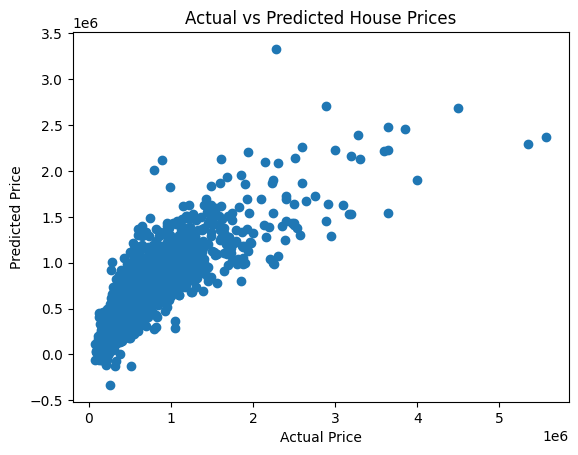

In [41]:
plt.scatter(Y_test, Y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")
plt.show()